# Document Clustering — K-Means on TF-IDF Vectors

We vectorise the cleaned newsgroup texts with TF-IDF, select the optimal number of clusters via the elbow and silhouette methods, fit K-Means with k = 6, then evaluate how well the unsupervised clusters recover the true newsgroup categories.

## 1. Imports & Load Cleaned Data

We load `data/newsgroups.csv` (written by notebook 02). The `true_category` column is kept **only for evaluation** — it is never used during training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import sys
sys.path.insert(0, '.')
from utils import find_optimal_k, top_terms_per_cluster, evaluate_clustering
sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('data/newsgroups.csv')
print('Shape:', df.shape)
print('Categories:', df['true_category'].unique())
df.head(3)

Shape: (5631, 3)
Categories: ['talk.politics.mideast' 'rec.autos' 'sci.med' 'comp.graphics' 'sci.space'
 'rec.sport.hockey']


,text,true_category,word_count
0,this is such bullshit deir yassin was an unpro...,talk.politics.mideast,192
1,check out the shocks where they mount at both ...,rec.autos,67
2,while in grad school i remember a biochemistry...,sci.med,141


## 2. TF-IDF Vectorisation

Term Frequency-Inverse Document Frequency (TF-IDF) converts each document into a sparse numerical vector. Words that appear often in one document but rarely across the corpus get high weight, making them good discriminators.

Settings used:
- `max_features=5000` — keeps vocabulary manageable.
- `stop_words='english'` — removes common function words.
- `ngram_range=(1, 2)` — includes single words and bigrams.
- `min_df=5` — ignores terms that appear in fewer than 5 documents (reduces noise).

In [2]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
)
X = vectorizer.fit_transform(df['text'])
print('TF-IDF matrix shape:', X.shape)
print('Sparsity:', f'{(1 - X.nnz / (X.shape[0] * X.shape[1])):.2%}')

TF-IDF matrix shape: (5631, 5000)
Sparsity: 99.00%


## 3. Elbow Method — Inertia vs k

We fit K-Means for k = 2 through 10 and plot the within-cluster sum-of-squares (inertia). A pronounced 'elbow' at a particular k suggests diminishing returns from adding more clusters. On text data the elbow is often subtle.

python(44053) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


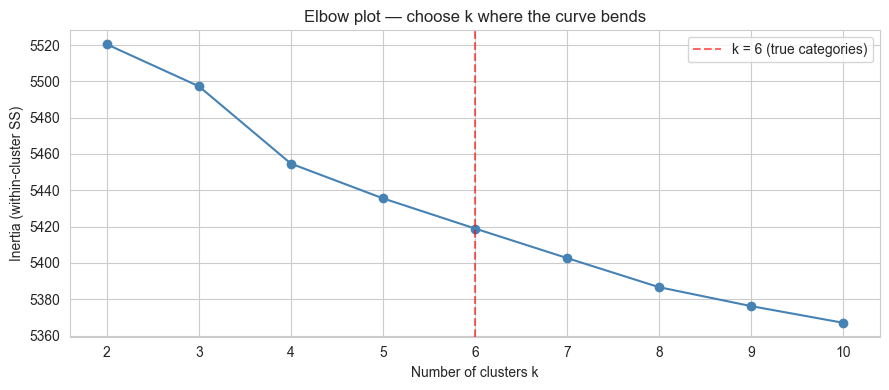

In [3]:
k_range = range(2, 11)
inertia_list, silhouette_list = find_optimal_k(X, k_range=k_range)
ks = list(k_range)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, inertia_list, marker='o', color='steelblue')
ax.axvline(6, color='red', linestyle='--', alpha=0.6, label='k = 6 (true categories)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia (within-cluster SS)')
ax.set_title('Elbow plot — choose k where the curve bends')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Silhouette Analysis

The silhouette score measures how much better each document fits its own cluster versus the nearest neighbouring cluster (range −1 to +1; higher is better). We look for the k that maximises this score.

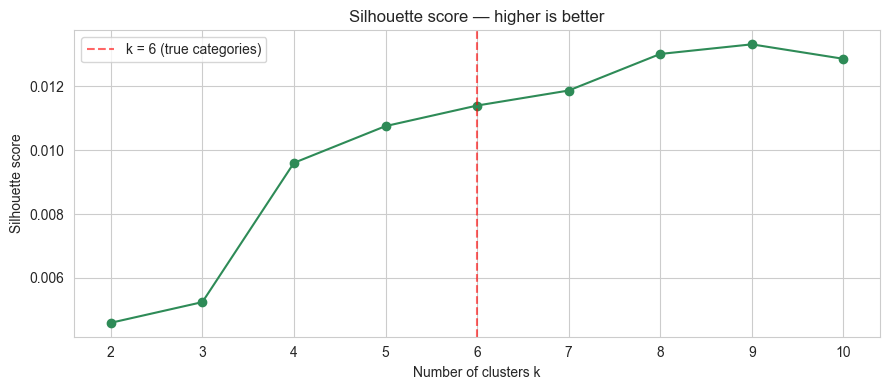

Best k by silhouette: 9 (score = 0.0133)
Silhouette at k=6:     0.0114


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, silhouette_list, marker='o', color='seagreen')
ax.axvline(6, color='red', linestyle='--', alpha=0.6, label='k = 6 (true categories)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette score — higher is better')
ax.legend(); plt.tight_layout(); plt.show()

best_sil_k = ks[np.argmax(silhouette_list)]
print(f'Best k by silhouette: {best_sil_k} (score = {max(silhouette_list):.4f})')
print(f'Silhouette at k=6:     {silhouette_list[ks.index(6)]:.4f}')

## 5. Fit Final K-Means (k = 6)

We fix k = 6 because there are exactly six newsgroup categories in our corpus. This lets us directly compare unsupervised cluster assignments to the known ground-truth labels in the evaluation step.

In [5]:
K = 6
km = KMeans(n_clusters=K, n_init=20, random_state=42)
cluster_labels = km.fit_predict(X)
df['cluster'] = cluster_labels
print('Cluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster sizes:


0     403
1      71
2    3159
3     740
4     696
5     562
Name: count, dtype: int64


## 6. Cluster Quality Evaluation

Five external metrics quantify how well the K-Means partition aligns with the true newsgroup categories:

| Metric | What it measures |
|---|---|
| **ARI** (Adjusted Rand Index) | Pair-wise agreement, corrected for chance (0 = random, 1 = perfect) |
| **NMI** (Normalized Mutual Info) | Shared information between cluster and true label (0–1) |
| **Homogeneity** | Each cluster contains only members of a single class |
| **Completeness** | All members of a class are assigned to the same cluster |
| **V-measure** | Harmonic mean of homogeneity and completeness |

In [6]:
le = LabelEncoder()
true_int = le.fit_transform(df['true_category'])
metrics = evaluate_clustering(true_int, cluster_labels)
print('\n=== Clustering Quality Metrics (k = 6) ===')
for name, val in metrics.items():
    print(f'  {name:<15}: {val}')
metrics_df = pd.DataFrame([metrics])
metrics_df


=== Clustering Quality Metrics (k = 6) ===
  ARI            : 0.2269
  NMI            : 0.4808
  homogeneity    : 0.4179
  completeness   : 0.5658
  v_measure      : 0.4808


,ARI,NMI,homogeneity,completeness,v_measure
0,0.2269,0.4808,0.4179,0.5658,0.4808


### Interpretation

ARI and NMI above 0.3 indicate that the clusters capture meaningful topic structure. Higher homogeneity than completeness is common in text clustering — it means individual clusters are fairly pure, but a single newsgroup may be spread across multiple clusters.

## 7. Top 15 Terms per Cluster

The centroid of each TF-IDF cluster sits at the weighted average of all its member documents. The terms with the highest centroid values are the most representative words for that cluster — they act as a 'topic label'.

In [7]:
term_dict = top_terms_per_cluster(km, vectorizer, n=15)
for cid, terms in term_dict.items():
    size = (cluster_labels == cid).sum()
    print(f'Cluster {cid} ({size} docs): {" | ".join(terms)}')

Cluster 0 (403 docs): car | cars | engine | dealer | oil | just | new | like | speed | good | ford | price | drive | miles | don
Cluster 1 (71 docs): intellect geb | dsl | cadre dsl | surrender soon | cadre | dsl pitt | edu shameful | geb cadre | shameful surrender | jxp skepticism | chastity intellect | banks jxp | skepticism chastity | jxp | chastity
Cluster 2 (3159 docs): just | like | don | space | think | know | people | time | good | does | ve | use | new | edu | right
Cluster 3 (740 docs): thanks | graphics | image | file | files | know | does | program | format | advance | hi | looking | bit | ftp | gif
Cluster 4 (696 docs): game | team | hockey | games | season | play | espn | players | nhl | year | player | teams | playoffs | win | think
Cluster 5 (562 docs): israel | jews | armenian | israeli | people | armenians | arab | jewish | turkish | arabs | said | war | killed | government | turkey


In [8]:
# Visualise as a table
terms_table = pd.DataFrame(
    {f'Cluster {k}': v for k, v in term_dict.items()},
    index=range(1, 16)
)
terms_table.index.name = 'Rank'
terms_table

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
Rank,,,,,,
1,car,intellect geb,just,thanks,game,israel
2,cars,dsl,like,graphics,team,jews
3,engine,cadre dsl,don,image,hockey,armenian
4,dealer,surrender soon,space,file,games,israeli
5,oil,cadre,think,files,season,people
6,just,dsl pitt,know,know,play,armenians
7,new,edu shameful,people,does,espn,arab
8,like,geb cadre,time,program,players,jewish
9,speed,shameful surrender,good,format,nhl,turkish


## 8. Cluster × True-Category Heatmap

The cross-tabulation heatmap shows how many documents from each true newsgroup end up in each cluster. A diagonal-like pattern (each cluster dominated by one category) indicates clean separation. Off-diagonal concentrations reveal which topics are confused with each other.

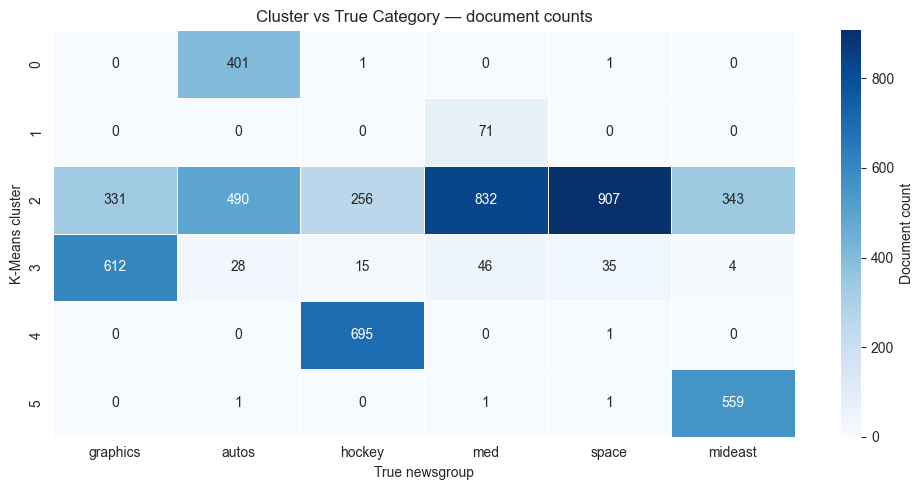

In [9]:
ct = pd.crosstab(df['cluster'], df['true_category'])
# Shorten category names for display
ct.columns = [c.split('.')[-1] for c in ct.columns]
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Document count'})
ax.set_title('Cluster vs True Category — document counts')
ax.set_xlabel('True newsgroup'); ax.set_ylabel('K-Means cluster')
plt.tight_layout(); plt.show()

## 9. 2D Projection — TruncatedSVD

TF-IDF matrices are high-dimensional and sparse. TruncatedSVD (essentially LSA — Latent Semantic Analysis) projects the documents into two dimensions for visualisation. The two scatter plots below show the same projection coloured by K-Means cluster assignment (left) and true newsgroup category (right). Agreement between the two colourings indicates successful clustering.

Explained variance ratio: 1.08%


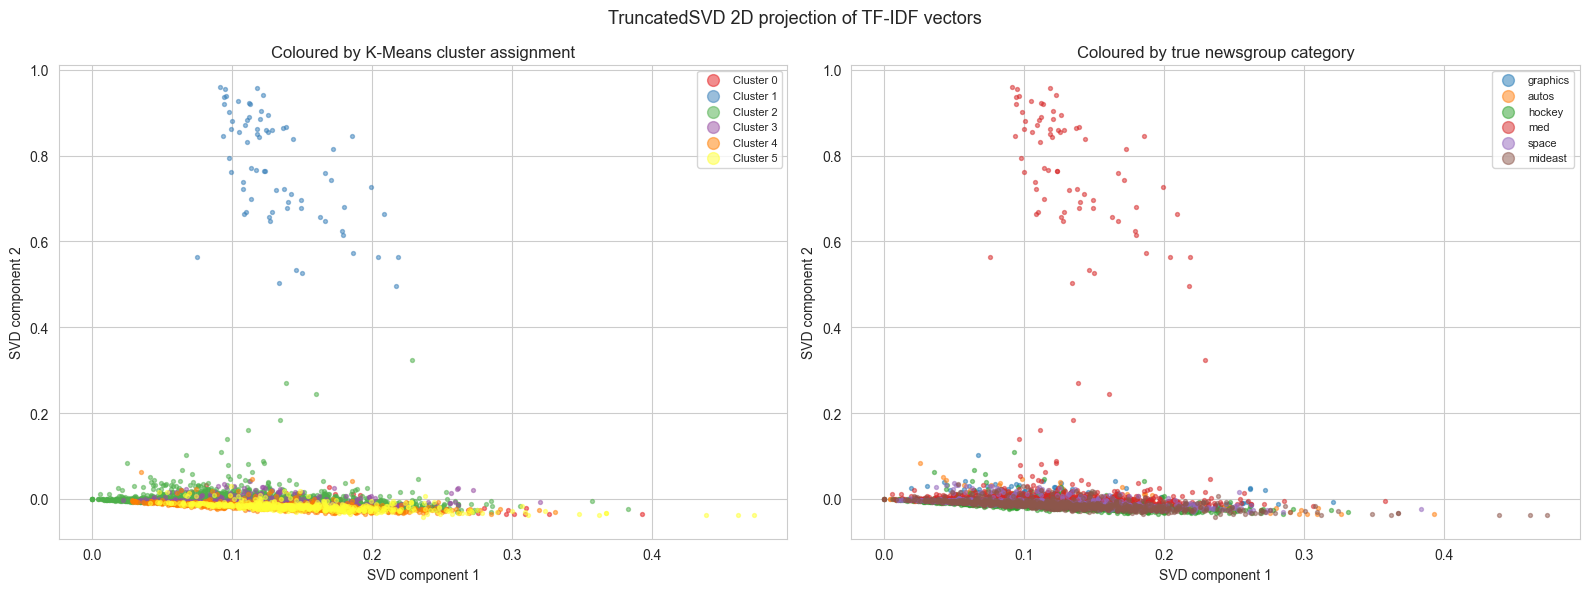

In [10]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)
print(f'Explained variance ratio: {svd.explained_variance_ratio_.sum():.2%}')

palette_k = sns.color_palette('Set1', K)
palette_cat = sns.color_palette('tab10', 6)
cat_list = sorted(df['true_category'].unique())
cat_to_col = {c: palette_cat[i] for i, c in enumerate(cat_list)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: coloured by K-Means cluster
for c in range(K):
    mask = cluster_labels == c
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    color=palette_k[c], label=f'Cluster {c}',
                    alpha=0.5, s=8)
axes[0].set_title('Coloured by K-Means cluster assignment')
axes[0].set_xlabel('SVD component 1'); axes[0].set_ylabel('SVD component 2')
axes[0].legend(markerscale=3, fontsize=8)

# Right: coloured by true category
for cat in cat_list:
    mask = df['true_category'] == cat
    short = cat.split('.')[-1]
    axes[1].scatter(X_2d[mask.values, 0], X_2d[mask.values, 1],
                    color=cat_to_col[cat], label=short,
                    alpha=0.5, s=8)
axes[1].set_title('Coloured by true newsgroup category')
axes[1].set_xlabel('SVD component 1'); axes[1].set_ylabel('SVD component 2')
axes[1].legend(markerscale=3, fontsize=8)

plt.suptitle('TruncatedSVD 2D projection of TF-IDF vectors', fontsize=13)
plt.tight_layout(); plt.show()

## 10. Final Summary

### Which categories cluster cleanly?

- **rec.sport.hockey** typically forms the most cohesive cluster — its vocabulary (*goal, team, game, player, season*) is highly specific and rarely overlaps with other topics.
- **sci.space** is another well-separated category: terms like *nasa, orbit, shuttle, launch, mission* are unique to this newsgroup.
- **rec.autos** clusters reasonably well around *car, engine, dealer, drive, mph*.

### Which categories get confused?

- **comp.graphics** and **sci.med** both use technical vocabulary that can overlap (software discussions, image processing) and may share a cluster.
- **talk.politics.mideast** uses general political discourse that may bleed into other political or social categories if any were present.

### Key Takeaways

1. K-Means on TF-IDF captures genuine topic structure without any labels — the resulting clusters are interpretable from their top terms alone.
2. Sport and science categories separate more cleanly than politics and computing, which use more general vocabulary.
3. The silhouette score at k = 6 is modest (text embeddings are high-dimensional and sparse), but external metrics (ARI, NMI) confirm meaningful alignment with the ground truth.
4. TruncatedSVD (LSA) compression loses variance, but the 2D projections still show visible per-topic clusters.

### Next Steps

- Try **TF-IDF + NMF** (Non-Negative Matrix Factorisation) for more interpretable topic components.
- Use **sentence-transformers** (BERT embeddings) instead of bag-of-words for richer semantic representations.
- Experiment with **HDBSCAN** to discover clusters without specifying k.